<a href="https://colab.research.google.com/github/rohitv08/gemini-robotics/blob/main/Getting%20Started/gemini_robotics_er.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##### Copyright 2026 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gemini Quickstart: Gemini Robotics-ER

This notebook introduces the **Gemini Robotics-ER** model.

Gemini Robotics-ER is a vision-language model (VLM) that brings Gemini's agentic capabilities to robotics. It's designed for advanced reasoning in the physical world, allowing robots to interpret complex visual data, perform spatial reasoning, and plan actions from natural language commands.

Key features and benefits:

* **Enhanced autonomy:** Robots can reason, adapt, and respond to changes in open-ended environments.
* **Natural language interaction:** Makes robots easier to use by enabling complex task assignments using natural language.
* **Task orchestration:** Deconstructs natural language commands into subtasks and integrates with existing robot controllers and behaviors to complete long-horizon tasks.
* **Versatile capabilities:** Locates and identifies objects, understands object relationships, plans grasps and trajectories, and interprets dynamic scenes.
* **Agentic vision:** Uses code generation to zoom in on and analyze images in detail to make better decisions.

## Setup

This section will need to be run any time you start up Colab. The example sections following this are intended to be able to be run without reliance on any other example section, so you may skip through to the examples that are most relevant/interesting to you at the time (though it is strongly recommended that you read through each of these examples at least once!)

### Install SDK

In [1]:
%pip install -U -q google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 9.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires google-auth==2.47.0, but you have google-auth 2.49.2 which is incompatible.


### Setup your API key

To run the following cells, your API key must be stored in a Colab Secret named `GEMINI_API_KEY`. If you don't already have an API key, or you're not sure how to create a Colab Secret, see [Authentication](https://github.com/google-gemini/cookbook/blob/main/quickstarts/Authentication.ipynb) for an example.

In [2]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")

### Initialize SDK client

Initialize a Gemini SDK client with your API key.

In [3]:
from google import genai
from google.genai import types

client = genai.Client(api_key=GEMINI_API_KEY)

### Select the Gemini Robotics-ER model and test


In [4]:
MODEL_ID = "gemini-robotics-er-1.6-preview"

print(
    client.models.generate_content(
        model=MODEL_ID, contents="Are you there?"
    ).text
)

Yes, I am here. How can I help you today?


### Imports and utility code

#### Imports

In [5]:
import json
import textwrap
import time
import io

#### Parsing JSON output

In [6]:
def parse_json(json_output):
  # Parsing out the markdown fencing
  lines = json_output.splitlines()
  for i, line in enumerate(lines):
    if line == "```json":
      # Remove everything before "```json"
      json_output = "\n".join(lines[i + 1 :])
      # Remove everything after the closing "```"
      json_output = json_output.split("```")[0]
      break  # Exit the loop once "```json" is found
  return json_output

#### Resize images

Resize images for faster rendering and smaller API calls.

In [7]:
from PIL import Image

def get_image_resized(img_path):
    img = Image.open(img_path)
    img = img.resize(
        (800, int(800 * img.size[1] / img.size[0])), Image.Resampling.LANCZOS
    )
    return img

#### Visualization helpers

In [12]:
import base64
import dataclasses
from io import BytesIO
import numpy as np
from PIL import ImageColor, ImageDraw, ImageFont
from typing import Tuple

import IPython
from IPython import display

def generate_point_html(pil_image, points_json):
  buffered = BytesIO()
  pil_image.save(buffered, format="PNG")
  img_str = base64.b64encode(buffered.getvalue()).decode()
  points_json = parse_json(points_json)

  return f"""
<!DOCTYPE html>
<html>
<head>
    <title>Point Visualization</title>
    <style>
        body {{
            margin: 0;
            padding: 0;
            background: #fff;
            color: #000;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
        }}

        .point-overlay {{
            position: absolute;
            top: 0;
            left: 0;
            width: 100%;
            height: 100%;
            pointer-events: none;
        }}

        .point {{
            position: absolute;
            width: 12px;
            height: 12px;
            background-color: #2962FF;
            border: 2px solid #fff;
            border-radius: 50%;
            transform: translate(-50%, -50%);
            box-shadow: 0 0 40px rgba(41, 98, 255, 0.6);
            opacity: 0;
            transition: all 0.3s ease-in;
            pointer-events: auto;
        }}

        .point.visible {{
            opacity: 1;
        }}

        .point.fade-out {{
            animation: pointFadeOut 0.3s forwards;
        }}

        .point.highlight {{
            transform: translate(-50%, -50%) scale(1.1);
            background-color: #FF4081;
            box-shadow: 0 0 40px rgba(255, 64, 129, 0.6);
            z-index: 100;
        }}

        @keyframes pointFadeOut {{
            from {{
                opacity: 1;
            }}
            to {{
                opacity: 0.7;
            }}
        }}

        .point-label {{
            position: absolute;
            background-color: #2962FF;
            color: #fff;
            font-size: 14px;
            padding: 4px 12px;
            border-radius: 4px;
            transform: translate(20px, -10px);
            white-space: nowrap;
            opacity: 0;
            transition: all 0.3s ease-in;
            box-shadow: 0 0 30px rgba(41, 98, 255, 0.4);
            pointer-events: auto;
            cursor: pointer;
        }}

        .point-label.visible {{
            opacity: 1;
        }}

        .point-label.fade-out {{
            opacity: 0.45;
        }}

        .point-label.highlight {{
            background-color: #FF4081;
            box-shadow: 0 0 30px rgba(255, 64, 129, 0.4);
            transform: translate(20px, -10px) scale(1.1);
            z-index: 100;
        }}
    </style>
</head>
<body>
    <div id="container" style="position: relative;">
        <canvas id="canvas" style="background: #000;"></canvas>
        <div id="pointOverlay" class="point-overlay"></div>
    </div>

    <script>
        function annotatePoints(frame) {{
            // Add points with fade effect
            const pointsData = {points_json};

            const pointOverlay = document.getElementById("pointOverlay");
            pointOverlay.innerHTML = "";

            const points = [];
            const labels = [];

            pointsData.forEach(pointData => {{
                // Skip entries without coordinates.
                if (!(pointData.hasOwnProperty("point")))
                  return;

                const point = document.createElement("div");
                point.className = "point";
                const [y, x] = pointData.point;
                point.style.left = `${{x/1000.0 * 100.0}}%`;
                point.style.top = `${{y/1000.0 * 100.0}}%`;

                const pointLabel = document.createElement("div");
                pointLabel.className = "point-label";
                pointLabel.textContent = pointData.label;
                point.appendChild(pointLabel);

                pointOverlay.appendChild(point);
                points.push(point);
                labels.push(pointLabel);

                setTimeout(() => {{
                    point.classList.add("visible");
                    pointLabel.classList.add("visible");
                }}, 0);

                // Add hover effects
                const handleMouseEnter = () => {{
                    // Highlight current point and label
                    point.classList.add("highlight");
                    pointLabel.classList.add("highlight");

                    // Fade out other points and labels
                    points.forEach((p, idx) => {{
                        if (p !== point) {{
                            p.classList.add("fade-out");
                            labels[idx].classList.add("fade-out");
                        }}
                    }});
                }};

                const handleMouseLeave = () => {{
                    // Remove highlight from current point and label
                    point.classList.remove("highlight");
                    pointLabel.classList.remove("highlight");

                    // Restore other points and labels
                    points.forEach((p, idx) => {{
                        p.classList.remove("fade-out");
                        labels[idx].classList.remove("fade-out");
                    }});
                }};

                point.addEventListener("mouseenter", handleMouseEnter);
                point.addEventListener("mouseleave", handleMouseLeave);
                pointLabel.addEventListener("mouseenter", handleMouseEnter);
                pointLabel.addEventListener("mouseleave", handleMouseLeave);
            }});
        }}

        // Initialize canvas
        const canvas = document.getElementById("canvas");
        const ctx = canvas.getContext("2d");
        const container = document.getElementById("container");

        // Load and draw the image
        const img = new Image();
        img.onload = () => {{
            const aspectRatio = img.height / img.width;
            canvas.width = 800;
            canvas.height = Math.round(800 * aspectRatio);
            container.style.width = canvas.width + "px";
            container.style.height = canvas.height + "px";

            ctx.drawImage(img, 0, 0, canvas.width, canvas.height);

            frame.width = canvas.width;
            frame.height = canvas.height;
            annotatePoints(frame);
        }};
        img.src = "data:image/png;base64,{img_str}";

        const frame = {{
            width: canvas.width,
            height: canvas.height
        }};

        annotatePoints(frame);
    </script>
</body>
</html>
"""



additional_colors = [
    colorname for (colorname, colorcode) in ImageColor.colormap.items()
]

def plot_bounding_boxes(img, bounding_boxes):
  """Plots bounding boxes on an image.

  Plots bounding boxes on an image with markers for each a name, using PIL,
  normalized coordinates, and different colors.

  Args:
      img_path: The path to the image file.
      bounding_boxes: A list of bounding boxes containing the name of the object
        and their positions in normalized [y1 x1 y2 x2] format.
  """

  # Load the image
  width, height = img.size
  print(img.size)
  # Create a drawing object
  draw = ImageDraw.Draw(img)

  # Define a list of colors
  colors = [
      "red",
      "green",
      "blue",
      "yellow",
      "orange",
      "pink",
      "purple",
      "brown",
      "gray",
      "beige",
      "turquoise",
      "cyan",
      "magenta",
      "lime",
      "navy",
      "maroon",
      "teal",
      "olive",
      "coral",
      "lavender",
      "violet",
      "gold",
      "silver",
  ] + additional_colors

  # Parsing out the markdown fencing
  bounding_boxes = parse_json(bounding_boxes)

  font = ImageFont.truetype("LiberationSans-Regular.ttf", size=14)

  # Iterate over the bounding boxes
  for i, bounding_box in enumerate(json.loads(bounding_boxes)):
    # Select a color from the list
    color = colors[i % len(colors)]

    # Convert normalized coordinates to absolute coordinates
    abs_y1 = int(bounding_box["box_2d"][0] / 1000 * height)
    abs_x1 = int(bounding_box["box_2d"][1] / 1000 * width)
    abs_y2 = int(bounding_box["box_2d"][2] / 1000 * height)
    abs_x2 = int(bounding_box["box_2d"][3] / 1000 * width)

    if abs_x1 > abs_x2:
      abs_x1, abs_x2 = abs_x2, abs_x1

    if abs_y1 > abs_y2:
      abs_y1, abs_y2 = abs_y2, abs_y1

    # Draw the bounding box
    draw.rectangle(((abs_x1, abs_y1), (abs_x2, abs_y2)), outline=color, width=4)

    # Draw the text
    if "label" in bounding_box:
      draw.text(
          (abs_x1 + 8, abs_y1 + 6), bounding_box["label"], fill=color, font=font
      )

  # Display the image
  img


@dataclasses.dataclass(frozen=True)
class SegmentationMask:
  # bounding box pixel coordinates (not normalized)
  y0: int  # in [0..height - 1]
  x0: int  # in [0..width - 1]
  y1: int  # in [0..height - 1]
  x1: int  # in [0..width - 1]
  mask: np.array  # [img_height, img_width] with values 0..255
  label: str


def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
  items = json.loads(parse_json(predicted_str))
  masks = []
  for item in items:
    raw_box = item["box_2d"]
    abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
    abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
    abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
    abs_x1 = int(item["box_2d"][3] / 1000 * img_width)
    if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
      print("Invalid bounding box", item["box_2d"])
      continue
    label = item["label"]
    png_str = item["mask"]
    if not png_str.startswith("data:image/png;base64,"):
      print("Invalid mask")
      continue
    png_str = png_str.removeprefix("data:image/png;base64,")
    png_str = base64.b64decode(png_str)
    mask = Image.open(BytesIO(png_str))
    bbox_height = abs_y1 - abs_y0
    bbox_width = abs_x1 - abs_x0
    if bbox_height < 1 or bbox_width < 1:
      print("Invalid bounding box")
      continue
    mask = mask.resize(
        (bbox_width, bbox_height), resample=Image.Resampling.BILINEAR
    )
    np_mask = np.zeros((img_height, img_width), dtype=np.uint8)
    np_mask[abs_y0:abs_y1, abs_x0:abs_x1] = mask
    masks.append(
        SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, np_mask, label)
    )
  return masks


def overlay_mask_on_img(
    img: Image, mask: np.ndarray, color: str, alpha: float = 0.7
) -> Image.Image:
  """Overlays a single mask onto a PIL Image using a named color.

  The mask image defines the area to be colored. Non-zero pixels in the
  mask image are considered part of the area to overlay.

  Args:
      img: The base PIL Image object.
      mask: A PIL Image object representing the mask. Should have the same
        height and width as the img. Modes '1' (binary) or 'L' (grayscale) are
        typical, where non-zero pixels indicate the masked area.
      color: A standard color name string (e.g., 'red', 'blue', 'yellow').
      alpha: The alpha transparency level for the overlay (0.0 fully
        transparent, 1.0 fully opaque). Default is 0.7 (70%).

  Returns:
      A new PIL Image object (in RGBA mode) with the mask overlaid.

  Raises:
      ValueError: If color name is invalid, mask dimensions mismatch img
                  dimensions, or alpha is outside the 0.0-1.0 range.
  """
  if not (0.0 <= alpha <= 1.0):
    raise ValueError("Alpha must be between 0.0 and 1.0")

  # Convert the color name string to an RGB tuple
  try:
    color_rgb: Tuple[int, int, int] = ImageColor.getrgb(color)
  except ValueError as e:
    # Re-raise with a more informative message if color name is invalid
    raise ValueError(
        f"Invalid color name '{color}'. Supported names are typically HTML/CSS "
        f"color names. Error: {e}"
    )

  # Prepare the base image for alpha compositing
  img_rgba = img.convert("RGBA")
  width, height = img_rgba.size

  # Create the colored overlay layer
  # Calculate the RGBA tuple for the overlay color
  alpha_int = int(alpha * 255)
  overlay_color_rgba = color_rgb + (alpha_int,)

  # Create an RGBA layer (all zeros = transparent black)
  colored_mask_layer_np = np.zeros((height, width, 4), dtype=np.uint8)

  # Mask has values between 0 and 255, threshold at 127 to get binary mask.
  mask_np_logical = mask > 127

  # Apply the overlay color RGBA tuple where the mask is True
  colored_mask_layer_np[mask_np_logical] = overlay_color_rgba

  # Convert the NumPy layer back to a PIL Image
  colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, "RGBA")

  # Composite the colored mask layer onto the base image
  result_img = Image.alpha_composite(img_rgba, colored_mask_layer_pil)

  return result_img


def plot_segmentation_masks(
    img: Image, segmentation_masks: list[SegmentationMask]
):
  """Plots bounding boxes on an image.

  Plots bounding boxes on an image with markers for each a name, using PIL,
  normalized coordinates, and different colors.

  Args:
      img: The PIL.Image.
      segmentation_masks: A string encoding as JSON a list of segmentation masks
        containing the name of the object, their positions in normalized [y1 x1
        y2 x2] format, and the png encoded segmentation mask.
  """
  # Define a list of colors
  colors = [
      "red",
      "green",
      "blue",
      "yellow",
      "orange",
      "pink",
      "purple",
      "brown",
      "gray",
      "beige",
      "turquoise",
      "cyan",
      "magenta",
      "lime",
      "navy",
      "maroon",
      "teal",
      "olive",
      "coral",
      "lavender",
      "violet",
      "gold",
      "silver",
  ] + additional_colors

  font = ImageFont.load_default()

  # Do this in 3 passes to make sure the boxes and text are always visible.

  # Overlay the mask
  for i, mask in enumerate(segmentation_masks):
    color = colors[i % len(colors)]
    img = overlay_mask_on_img(img, mask.mask, color)

  # Create a drawing object
  draw = ImageDraw.Draw(img)

  # Draw the bounding boxes
  for i, mask in enumerate(segmentation_masks):
    color = colors[i % len(colors)]
    draw.rectangle(
        ((mask.x0, mask.y0), (mask.x1, mask.y1)), outline=color, width=4
    )

  # Draw the text labels
  for i, mask in enumerate(segmentation_masks):
    color = colors[i % len(colors)]
    if mask.label != "":
      draw.text((mask.x0 + 8, mask.y0 - 20), mask.label, fill=color, font=font)
  return img


def overlay_points_on_frames(original_frames, points_data_per_frame):
  """Overlays points on original frames and returns the modified frames."""
  modified_frames = []

  # Define colors for drawing points (using a consistent color per label for clarity)
  label_colors = {}
  current_color_index = 0
  available_colors = [
      "red",
      "green",
      "blue",
      "yellow",
      "orange",
      "pink",
      "purple",
      "brown",
      "gray",
      "beige",
      "turquoise",
      "cyan",
      "magenta",
      "lime",
      "navy",
      "maroon",
      "teal",
      "olive",
      "coral",
      "lavender",
      "violet",
      "gold",
      "silver",
  ]

  font = ImageFont.load_default()

  # Check if the number of original frames matches the number of processed data entries
  if len(original_frames) != len(points_data_per_frame):
    print(
        f"Error: Number of original frames ({len(original_frames)}) does not "
        "match the number of processed point data entries"
        f" ({len(points_data_per_frame)}). Cannot overlay points accurately."
    )
    return original_frames  # Return original frames if data doesn't match
  else:
    # Iterate through the frames and draw points
    for i, frame_pil in enumerate(original_frames):
      # Ensure frame is in RGB mode for drawing
      img = frame_pil.convert("RGB")
      draw = ImageDraw.Draw(img)
      width, height = img.size

      frame_points = points_data_per_frame[i]

      # Draw points on the frame
      for point_info in frame_points:
        if "point" in point_info and "label" in point_info:
          y_norm, x_norm = point_info["point"]
          label = point_info["label"]

          # Get color for the label
          if label not in label_colors:
            label_colors[label] = available_colors[
                current_color_index % len(available_colors)
            ]
            current_color_index += 1
          color = label_colors[label]

          # Convert normalized coordinates to absolute pixel coordinates
          abs_x = int(x_norm / 1000.0 * width)
          abs_y = int(y_norm / 1000.0 * height)

          # Draw a circle at the point
          point_radius = 5
          draw.ellipse(
              (
                  abs_x - point_radius,
                  abs_y - point_radius,
                  abs_x + point_radius,
                  abs_y + point_radius,
              ),
              fill=color,
              outline=color,
          )

          # Draw the label
          # Adjust label position to avoid going out of bounds
          label_pos_x = abs_x + point_radius + 2
          label_pos_y = (
              abs_y - point_radius - 10
              if abs_y - point_radius - 10 > 0
              else abs_y + point_radius + 2
          )
          draw.text((label_pos_x, label_pos_y), label, fill=color, font=font)

      # Append the modified PIL Image
      modified_frames.append(img)

    print(f"Processed and drew points on {len(modified_frames)} frames.")
    return modified_frames


def display_gif(frames_to_display):
  """Saves and displays a list of PIL Images as a GIF."""
  if frames_to_display:
    try:
      # Save the modified frames as a new GIF
      output_gif_path = "/tmp/annotated_aloha_pen.gif"
      # Duration per frame in milliseconds (adjust as needed, 40ms is 25fps)
      duration_ms = 40
      # Ensure all frames are in RGB mode before saving as GIF
      rgb_frames = [frame.convert("RGB") for frame in frames_to_display]
      if rgb_frames:
        rgb_frames[0].save(
            output_gif_path,
            save_all=True,
            append_images=rgb_frames[1:],
            duration=duration_ms,
            loop=0,
        )

        # Display the GIF in Colab
        display.display(display.Image(output_gif_path))
        print(f"Displayed annotated GIF: {output_gif_path}")
      else:
        print("No frames to create GIF.")

    except Exception as e:
      print(f"Error creating or displaying annotated GIF: {e}")
  else:
    print("No frames to display.")


def extract_frames(gif):
  """Extracts frames from a GIF and returns a list of PIL Image objects."""
  frames = []
  try:
    while True:
      # Convert each frame to RGB to ensure compatibility with drawing
      frame = gif.convert("RGB")
      frames.append(frame)
      gif.seek(gif.tell() + 1)  # Move to the next frame
  except EOFError:
    pass  # End of sequence

  print(f"Extracted {len(frames)} frames from the GIF.")

  return frames


def populate_points_for_all_frames(total_frames, step, analyzed_data):
  """Populates point data for all frames based on analyzed frames."""
  points_data_all_frames = []
  analyzed_data_index = 0
  for i in range(total_frames):
    if i % step == 0 and analyzed_data_index < len(analyzed_data):
      points_data_all_frames.append(analyzed_data[analyzed_data_index])
      analyzed_data_index += 1
    else:
      # For frames that were not analyzed, use the data from the last analyzed
      # frame or append an empty list if no frame has been analyzed yet
      if analyzed_data_index > 0:
        points_data_all_frames.append(analyzed_data[analyzed_data_index - 1])
      else:
        # Should not happen if frames list is not empty
        points_data_all_frames.append([])
  return points_data_all_frames

## Common settings

Many of the examples work well with thinking turned off to reduce latency.

Most of the examples use a common recipe to call the model - an image, a prompt, and a `GenerateContentConfig`. This function reduces code duplication and highlights when different settings are used.

In [8]:
def call_gemini_robotics_er(img, prompt, config=None):
    default_config = types.GenerateContentConfig(
        temperature=1.0,
        thinking_config=types.ThinkingConfig(thinking_budget=0)
    )

    if config is None:
        config = default_config

    image_response = client.models.generate_content(
          model=MODEL_ID,
          contents=[img, prompt],
          config=config,
    )

    return parse_json(image_response.text)

## 2D Pointing

In [9]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/aloha-arms-table.png -O aloha-arms-table.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/gameboard.png -O gameboard.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/washers.png -O washer.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/aloha-pen.gif -O aloha-pen.gif -q

### Pointing to Undefined Objects


Total processing time: 3.3158 seconds



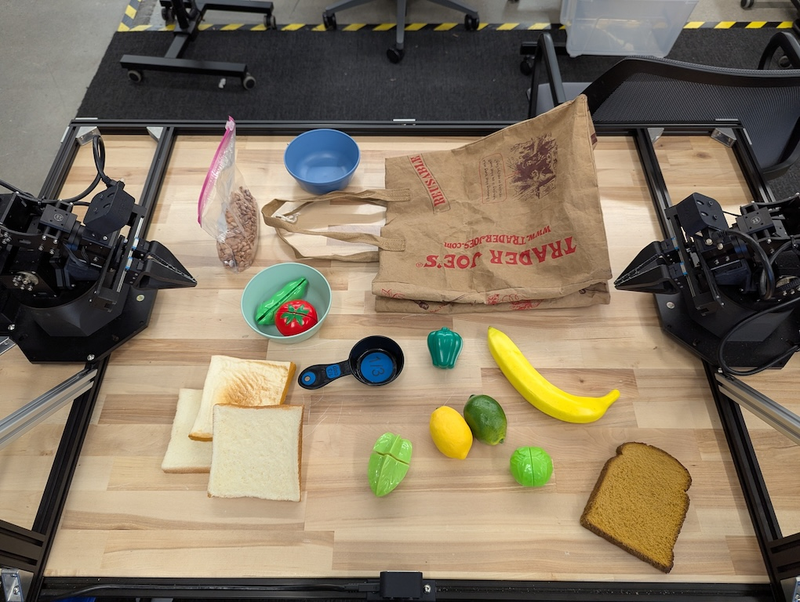

In [13]:
import IPython

img = get_image_resized("aloha-arms-table.png")

prompt = textwrap.dedent("""\
    Point to no more than 10 items in the image. The label returned should be an
    identifying name for the object detected.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json_output))

### Pointing to Defined Objects

In [ ]:
img = get_image_resized("aloha-arms-table.png")

queries = [
    "bread",
    "starfruit",
    "banana",
]

prompt = textwrap.dedent(f"""\
Get all points matching the following objects: {', '.join(queries)}. The label
returned should be an identifying name for the object detected.

The answer should follow the JSON format:
[{{"point": <point>, "label": <label1>}}, ...]

The points are in [y, x] format normalized to 0-1000.
""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

points_data = []
try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print("Warning: Invalid JSON response. Skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Point to all instances of an object based on more abstract description (e.g. "fruit")

In [ ]:
points_data = []
img = get_image_resized("aloha-arms-table.png")

prompt = textwrap.dedent(f"""\
        Get all points for fruit. The label returned should be an identifying
        name for the object detected.

        The answer should follow the json format:
        [{{"point": <point>, "label": <label1>}}, ...]

        The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print(f"Warning: Invalid JSON response, skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Point to all instances of an object

In [ ]:
points_data = []
img = get_image_resized("gameboard.png")

queries = [
    "game board slot",
    "X game piece",
]

start_time = time.time()
for obj in queries:
  prompt = textwrap.dedent(f"""\
      Get all points matching {obj}. The label returned should be an identifying
      name for the object detected.

      The answer should follow the JSON format:
      [{{"point": <point>, "label": <label1>}}, ...]

      The points are in [y, x] format normalized to 0-1000.""")
  json_output = call_gemini_robotics_er(img, prompt)

  try:
    data = json.loads(json_output)
    points_data.extend(data)
  except json.JSONDecodeError:
    print(f"Warning: Invalid JSON response for {obj}. Skipping.")
    continue

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Pointing to certain parts of an object in parallel

In [ ]:
import concurrent.futures

img = get_image_resized("aloha-arms-table.png")
points_data = []

queries = [
    ("paper bag", "handles"),
    ("banana", "the stem"),
    ("banana", "center"),
    ("starfruit", "center"),
    ("lime", "center"),
    ("light blue bowl", "rim"),
    ("dark blue bowl", "rim"),
    ("measuring cup", "rim"),
    ("measuring cup", "handle"),
    ("bowl", "tomato"),
]

def process_query(obj, part):
  POINT_PROMPT_TEMPLATE = textwrap.dedent("""\
    Point to the $part of the $object in the image. Return the answer as a
    JSON list of a dictionary with keys 'point' and 'label'. Only return one
    point for this request.""")
  prompt = POINT_PROMPT_TEMPLATE.replace("$object", obj).replace("$part", part)
  json_output = call_gemini_robotics_er(img, prompt)
  try:
    data = json.loads(json_output)
    return data
  except json.JSONDecodeError:
    print(f"Warning: Invalid JSON response for {obj}, {part}. Skipping.")
    return []

start_time = time.time()
with concurrent.futures.ThreadPoolExecutor() as executor:
  results = executor.map(
      lambda query: process_query(query[0], query[1]), queries
  )

for result in results:
  points_data.extend(result)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Counting by Pointing

In [ ]:
img = get_image_resized("washer.png")

prompt = textwrap.dedent("""\
    Point to each washer in the box. Return the answer in the format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

try:
  data = json.loads(json_output)
  print(f"count: {len(data)}")
except json.JSONDecodeError:
  print("Error: Could not decode JSON response from the model.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json_output))

### Pointing to Defined Objects in a GIF

In [ ]:
gif_path = "aloha-pen.gif"
try:
  gif = Image.open(gif_path)
  print(f"Successfully loaded GIF: {gif_path}")
except FileNotFoundError:
  print(f"Error: GIF file not found at {gif_path}")
  raise

frames = extract_frames(gif)

# Define the objects to query
queries = [
    "pen (on desk)",
    "pen (in robot hand)",
    "laptop (opened)",
    "laptop (closed)",
]

prompt = textwrap.dedent(f"""\
Point to the following objects in the provided image: {", ".join(queries)}.

The answer should follow the JSON format:
[{{"point": <point>, "label": <label1>}}, ...]

The points are in [y, x] format normalized to 0-1000.

If no objects are found, return an empty JSON list [].""")


# Send every 10th frame as a separate request for the sake of time
analyzed_frames_data = []
frame_step = 10

for i in range(0, len(frames), frame_step):
  frame_index = i
  frame = frames[frame_index]
  print(f"Processing frame {frame_index+1}/{len(frames)}...")

  try:
    image_response = client.models.generate_content(
        model=MODEL_ID,
        contents=[frame, prompt],
        config=types.GenerateContentConfig(
            temperature=1.0,
            thinking_config=types.ThinkingConfig(thinking_budget=0),
        ),
    )

    try:
      json_output = parse_json(image_response.text)
      frame_points = json.loads(json_output)
      analyzed_frames_data.append(frame_points)
      print(
          f"  Successfully parsed {len(frame_points)} points for frame"
          f" {frame_index+1}."
      )
    except json.JSONDecodeError as e:
      print(
          f"  Error decoding JSON for frame {frame_index+1}: {e}. Appending"
          " empty list."
      )
      analyzed_frames_data.append([])
    except Exception as e:
      print(
          "  An unexpected error occurred processing frame"
          f" {frame_index+1} response: {e}. Appending empty list."
      )
      analyzed_frames_data.append([])

  except Exception as e:
    print(
        f"  Error generating content for frame {frame_index+1}: {e}. Appending"
        " empty list."
    )
    analyzed_frames_data.append([])


print(f"Collected point data for {len(analyzed_frames_data)} analyzed frames.")

points_data_all_frames = populate_points_for_all_frames(
    len(frames), frame_step, analyzed_frames_data
)
print(f"Populated point data for {len(points_data_all_frames)} total frames.")


modified_frames = overlay_points_on_frames(frames, points_data_all_frames)
display_gif(modified_frames)

## Object Detection and Bounding Boxes

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/aloha-arms-table.png -O aloha-arms-table.png -q

### 2D Bounding boxes

In [ ]:
img = get_image_resized("aloha-arms-table.png")

prompt = textwrap.dedent("""\
      Return bounding boxes as a JSON array with labels. Never return masks or
      code fencing. Limit to 25 objects. Include as many objects as you can
      identify on the table.
      If an object is present multiple times, name them according to their
      unique characteristic (colors, size, position, unique characteristics,
      etc..).
      The format should be as follows:
      [{"box_2d": [ymin, xmin, ymax, xmax], "label": <label for the object>}]
      normalized to 0-1000. The values in box_2d must only be integers.
""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

plot_bounding_boxes(img, json_output)
img

## Trajectories

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/aloha_desk.png -O aloha_desk.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/particles.jpg -O particles.jpg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/livingroom.jpeg -O livingroom.jpeg -q

### Simple Trajectory Planning

In [ ]:
img = get_image_resized("aloha_desk.png")
points_data = []

prompt = textwrap.dedent("""\
    Place a point on the red pen, then 15 points for the trajectory of moving
    the red pen to the top of the organizer on the left.

    The points should be labeled by order of the trajectory, from '0' (start
    point at left hand) to <n> (final point).

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
config=types.GenerateContentConfig(temperature=1.0)
json_output = call_gemini_robotics_er(img, prompt, config)

try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print("Warning: Invalid JSON response. Skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

In [ ]:
# @title Path for Brushing Particles

img = get_image_resized("particles.jpg")
points_data = []

prompt = textwrap.dedent("""\
    Point to the the blue brush and a list of 10 points covering the region of
    particles. Ensure that the points are spread evenly over the particles to
    create a smooth trajectory.

    Label the points from 1 to 10 based on the order that they should be
    approached in the trajectory of cleaning the plate. Movement should start
    from the brush.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
config=types.GenerateContentConfig(temperature=1.0)
json_output = call_gemini_robotics_er(img, prompt, config)

try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print("Warning: Invalid JSON response. Skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

### Obstacle-avoidance trajectory planning

In [ ]:
img = get_image_resized("livingroom.jpeg")
points_data = []

prompt = textwrap.dedent("""\
    Find the most direct collision-free trajectory of 10 points on the floor
    between the current view origin and the green ottoman in the back left.
    The points should avoid all other obstacles on the floor.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.
    """)

start_time = time.time()
config=types.GenerateContentConfig(temperature=1.0)
json_output = call_gemini_robotics_er(img, prompt, config)

try:
  data = json.loads(json_output)
  points_data.extend(data)
except json.JSONDecodeError:
  print("Warning: Invalid JSON response. Skipping.")

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json.dumps(points_data)))

## Spatial Reasoning

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/clear_space.png -O clear_space.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/desk_organization.mp4 -O desk_organization.mp4 -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/bookshelf.jpeg -O bookshelf.jpeg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/cart.png -O cart.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/sockets.jpeg -O sockets.jpeg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/weights.jpeg -O weights.jpeg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/lunch.png -O lunch.png -q

### Item to remove to make room for laptop

In [ ]:
img = get_image_resized("clear_space.png")

prompt = textwrap.dedent("""\
    Point to the object that I need to remove to make room for my laptop.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

config=types.GenerateContentConfig(
    temperature=1.0,
    thinking_config=types.ThinkingConfig(thinking_budget=1024),
)

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt, config)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json_output))

### Orchestrating: Packing a Lunch

In [ ]:
img = get_image_resized("lunch.png")
prompt = textwrap.dedent("""\
    Explain how to pack the lunch box and lunch bag. Point to each object that
    you refer to.

    Each point should be in the format:
    [{"point": [y, x], "label": }]
    where the coordinates are normalized between 0-1000.
    """)

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

print(json_output)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
img

### Empty electrical sockets

In [ ]:
img = get_image_resized("sockets.jpeg")
prompt = textwrap.dedent("""\
    Point to the unobstructed empty sockets.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json_output))

### Limiting item lift (3LB limit)

In [ ]:
img = get_image_resized("weights.jpeg")

prompt = textwrap.dedent("""\
    I am a robot with a payload of 3LBs. Point to all the objects in the image I
    am physically able to pick up.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
config=types.GenerateContentConfig(
    temperature=1.0,
    thinking_config=types.ThinkingConfig(thinking_budget=-1),
)
json_output = call_gemini_robotics_er(img, prompt, config)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json_output))

### Video Analysis

<video controls src="https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/desk_organization.mp4" width=600px>


In [ ]:
myfile = client.files.upload(file="/content/desk_organization.mp4")
while myfile.state == "PROCESSING":
  print(".", end="")
  time.sleep(1)
  myfile = client.files.get(name=myfile.name)

if myfile.state.name == "FAILED":
  raise ValueError(myfile.state.name)

print("Uploaded")

prompt = textwrap.dedent("""\
    Describe in detail each step of finishing the task. Breaking it down by
    timestamp, output in JSON format with keys "start_timestamp",
    "end_timestamp" and "description".""")

start_time = time.time()

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[myfile, prompt],
    config=types.GenerateContentConfig(
        temperature=1.0,
        thinking_config=types.ThinkingConfig(thinking_budget=-1),
    ),
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.4f} seconds")

print(response.text)

### Video Analysis: Time Range

In [ ]:
conversation_history = [
    {"role": "user", "parts": [{"text": prompt}]},
    {"role": "model", "parts": [{"text": response.text}]},
]

chat = client.chats.create(model=MODEL_ID, history=conversation_history)

prompt = textwrap.dedent("""\
    Zoom into second 15 to 22 and provide a per-second breakdown of what is
    happening in the same format.""")

start_time = time.time()

response = chat.send_message([prompt, myfile])

end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal processing time: {elapsed_time:.4f} seconds")

print(response.text)

### Finding the fourth row of shelves

In [ ]:
img = get_image_resized("bookshelf.jpeg")

prompt = textwrap.dedent("""\
    Return bounding boxes as a JSON array with labels highlighting all cubbies
    in the fourth row of shelves.

    The format should be as follows:
    [{"box_2d": [ymin, xmin, ymax, xmax], "label": <label for the object>}]

    normalized to 0-1000. The values in box_2d must only be integers.""")

start_time = time.time()
config=types.GenerateContentConfig(temperature=1.0)
json_output = call_gemini_robotics_er(img, prompt, config)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
plot_bounding_boxes(img, json_output)
img

### Finding shelves with specific items

In [ ]:
img = get_image_resized("bookshelf.jpeg")

prompt = textwrap.dedent("""\
    "I need to blow my nose."
    Find the cubby that can help.

    The format should be as follows:
    [{"box_2d": [ymin, xmin, ymax, xmax], "label": <label for the object>}]

    normalized to 0-1000. The values in box_2d must only be integers.""")

start_time = time.time()
config=types.GenerateContentConfig(temperature=1.0)
json_output = call_gemini_robotics_er(img, prompt, config)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
plot_bounding_boxes(img, json_output)
img

### Counting items with thinking

In [ ]:
img = get_image_resized("cart.png")

prompt = textwrap.dedent("""\
    How many items are inside of the cart basket?
    Please share your reasoning.""")

start_time = time.time()
config=types.GenerateContentConfig(temperature=1.0)
json_output = call_gemini_robotics_er(img, prompt, config)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

print(json_output)
img

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/initial_state_1.png -O initial_state_1.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/initial_state_2.png -O initial_state_2.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/initial_state_3.png -O initial_state_3.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/initial_state_4.png -O initial_state_4.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/current_state_1.png -O current_state_1.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/current_state_2.png -O current_state_2.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/current_state_3.png -O current_state_3.png -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/current_state_4.png -O current_state_4.png -q

### Multi-view correspondence and Success Detection

In [ ]:
initial_state_1 = Image.open("initial_state_1.png")
initial_state_2 = Image.open("initial_state_2.png")
initial_state_3 = Image.open("initial_state_3.png")
initial_state_4 = Image.open("initial_state_4.png")
current_state_1 = Image.open("current_state_1.png")
current_state_2 = Image.open("current_state_2.png")
current_state_3 = Image.open("current_state_3.png")
current_state_4 = Image.open("current_state_4.png")

prompt = textwrap.dedent("""\
    For this task, you will see a robot or human trying to perform the task of
    putting the mango into the brown container. You may see multiple camera
    views of the same scene. Some cameras are static and are mounted outside of
    the scene and some cameras are mounted on the robot arms and thus they are
    moving during the episode.

    The first 4 images show multiple camera views from the start of the episode
    (some time ago). The last 4 images show multiple camera views from the
    current moment in the episode (as it is now).

    Looking at these images and comparing the start of the episode with current
    state did the robot successfully perform the task "put the mango into the
    brown container"?

    Answer only with (1) yes or (2) no. Return the number (1) or (2) that best
    answers the question.""")

start_time = time.time()

response = client.models.generate_content(
    model=MODEL_ID,
    contents=[
        initial_state_1,
        initial_state_2,
        initial_state_3,
        initial_state_4,
        current_state_1,
        current_state_2,
        current_state_3,
        current_state_4,
        prompt
    ],
    config=types.GenerateContentConfig(temperature=1.0),
)

end_time = time.time()
elapsed_time = end_time - start_time

print(f"\nTotal processing time: {elapsed_time:.4f} seconds")
print(f"Success? {'Yes' if response.text == '(1)' else 'No'}")

## Task Orchestration

To demonstrate task orchestration with your own custom robot API, this example will introduce a mock API that can be used for a simple pick-and-place operation. Both the block and the container where the block should be placed will be located and highlighted, and then the series of functions provided to the API will be called with appropriate logic for performing the action. This will use an origin system with 0,0 in a corner rather than on the robot.

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/er-example-colab/soarm-block.png -O soarm-block.png -q

### Locate relevant objects

In [ ]:
img = get_image_resized("soarm-block.png")
points_data = []

prompt = textwrap.dedent("""\
    Locate and point to the blue block and the orange bowl. The label returned
    should be an identifying name for the object detected.

    The answer should follow the JSON format:
    [{"point": <point>, "label": <label1>}, ...]

    The points are in [y, x] format normalized to 0-1000.""")

start_time = time.time()
json_output = call_gemini_robotics_er(img, prompt)

data = json.loads(json_output)
points_data.extend(data)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")
IPython.display.HTML(generate_point_html(img, json_output))

### Use location of relevant objects to call functions and perform pick-and-place

In [ ]:
# Define the robot's origin point so coordinates can be based on robot location
# for movements rather than original origin from the corner.

def move(x, y, high):
  print(f"moving to coordinates: {x}, {y}, {15 if high else 5}")


def setGripperState(opened):
  print("Opening gripper" if opened else "Closing gripper")


def returnToOrigin():
  print("Returning to origin pose")


robot_origin_y = 300
robot_origin_x = 500

blue_block_point = None
orange_bowl_point = None

for item in points_data:
  if item.get("label") == "blue block":
    blue_block_point = item.get("point")
  elif item.get("label") == "orange bowl":
    orange_bowl_point = item.get("point")

if blue_block_point and orange_bowl_point:
  block_y, block_x = blue_block_point
  bowl_y, bowl_x = orange_bowl_point

  print(f"Blue block normalized coordinates (y, x): {block_y}, {block_x}")
  print(f"Orange bowl normalized coordinates (y, x): {bowl_y}, {bowl_x}")

  block_relative_x = block_x - robot_origin_x
  block_relative_y = block_y - robot_origin_y
  bowl_relative_x = bowl_x - robot_origin_x
  bowl_relative_y = bowl_y - robot_origin_y

  prompt = textwrap.dedent(f"""\
      You are a robotic arm with six degrees-of-freedom. You have the following
      functions available to you:

      def move(x, y, high):
        # Moves the arm to the given coordinates. The boolean value 'high' set
        # to True means the robot arm should be lifted above the scene for
        # avoiding obstacles during motion. 'high' set to False means the robot
        # arm should have the gripper placed on the surface for interacting with
        # objects.

      def setGripperState(opened):
        # Opens the gripper if opened set to true, otherwise closes the gripper

      def returnToOrigin():
        # Returns the robot to an initial state. Should be called as a cleanup
        # operation.

      The origin point for calculating the moves is at normalized point
      y={robot_origin_y}, x={robot_origin_x}. Use this as the new (0,0) for
      calculating moves, allowing x and y to be negative.

      Perform a pick and place operation where you pick up the blue block at
      normalized coordinates ({block_x}, {block_y}) (relative coordinates:
      {block_relative_x}, {block_relative_y}) and place it into the orange bowl
      at normalized coordinates ({bowl_x}, {bowl_y}) (relative coordinates:
      {bowl_relative_x}, {bowl_relative_y}).
      Provide the sequence of function calls as a JSON list of objects, where
      each object has a "function" key (the function name) and an "args" key
      (a list of arguments for the function).

      Also, include your reasoning before the JSON output.

      For example:
      Reasoning: To pick up the block, I will first move the arm to a high
      position above the block, open the gripper, move down to the block, close
      the gripper, lift the arm, move to a high position above the bowl, move
      down to the bowl, open the gripper, and then lift the arm back to a high
      position.""")

  start_time = time.time()
  config=types.GenerateContentConfig(temperature=1.0)
  print("Model Response:")
  json_output = call_gemini_robotics_er(img, prompt, config)

  try:
    function_calls = json.loads(json_output)

    print("\nExecuting Function Calls:")
    for call in function_calls:
      function_name = call.get("function")
      arguments = call.get("args", [])

      if function_name == "move":
        move(*arguments)
      elif function_name == "setGripperState":
        setGripperState(*arguments)
      elif function_name == "returnToOrigin":
        returnToOrigin()
      else:
        print(f"Unknown function: {function_name}")

  except json.JSONDecodeError:
    print("Error: Could not parse JSON response from the model.")
  except Exception as e:
    print(f"An error occurred during function execution: {e}")

else:
  print("Could not find coordinates for both blue block and orange bowl.")

## New Capabilities with ER

### Reading a clock and applying logic

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/gemini-robotics-er/clock.jpg -O clock.jpg -q

In [ ]:
img = get_image_resized("clock.jpg")

q_time = 'What time is it? Is it a valid time that is possible? Always include validity, hours and minutes in your response. Include date, month and day of the week in your answer if they are explicitly shown.\n Please respond in the following JSON format:\n {\n  "valid": true OR false,\n  "hours": X,\n  "minutes": Y,\n "date": A OR false,\n  "month": B OR false,\n  "weekday": C OR false\n }. Zoom in or crop as necessary to confirm location of the clock hands.'
q_angle = 'What time is it going to be if we were to move the hour hand by 60 degrees forward (clockwise)?\n Use 12 or 24 hour format based on the original image.\n If the original time was invalid, include that in your response.\n Please respond in the following JSON format:\n {\n  "valid": true OR false,\n  "hours": X,\n  "minutes": Y,\n }. Zoom in or crop as necessary to confirm location of the clock hands.'

system_instruction = "Be precise. When JSON is requested, reply with ONLY that JSON (no preface, no code block)."

display.display(img)

response_time = call_gemini_robotics_er(img, system_instruction + " " + q_time)
print("Time Response:", response_time)

response_angle = call_gemini_robotics_er(img, system_instruction + " " + q_angle)
print("Angle change response: " + response_angle)

### Image zooming, cropping, rotating

In [ ]:
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/gemini-robotics-er/circuit_board.jpeg -O circuit_board.jpeg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/gemini-robotics-er/sorting.jpeg -O sorting.jpeg -q
!wget https://storage.googleapis.com/generativeai-downloads/images/robotics/gemini-robotics-er/meter.jpeg -O meter.jpeg -q

### Measuring fluid in a container

In [ ]:
img = Image.open("meter.jpeg")

prompt = """
How full is the meter of liquid?
To read it,
1) Find the points for the top of the sight window, bottom of the sight window and the liquid level, formatted as [y, x] with values ranging from 0-1000;
2) Use math to determine the liquid level as a percentage;
3) Output "Answer: ??" on a separate line, where ?? is a number without % or unit.
"""


start_time = time.time()
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[img, prompt],
    config=types.GenerateContentConfig(
        temperature=1.0,
        tools=[types.Tool(code_execution=types.ToolCodeExecution)],
    ),
)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    if part.executable_code is not None:
        print(part.executable_code.code)
    if part.code_execution_result is not None:
        print(part.code_execution_result.output)
    if part.as_image() is not None:
        # display() is a standard function in Jupyter/Colab notebooks
        display.display(Image.open(io.BytesIO(part.as_image().image_bytes)))

### Reading markings on a circuit board

In [ ]:
img = Image.open("circuit_board.jpeg")

prompt = "what is the number on the ESMT chip? zoom, crop, and rotate if needed."


start_time = time.time()
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[img, prompt],
    config=types.GenerateContentConfig(
        temperature=1.0,
        tools=[types.Tool(code_execution=types.ToolCodeExecution)],
    ),
)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    if part.executable_code is not None:
        print(part.executable_code.code)
    if part.code_execution_result is not None:
        print(part.code_execution_result.output)
    if part.as_image() is not None:
        display.display(Image.open(io.BytesIO(part.as_image().image_bytes)))

### Image Annotation

In [ ]:
img = Image.open("sorting.jpeg")

prompt = "Look at this image and return it as an annotated version using arrows of different colors to represent which items should go in which bins for disposal. You must return the final image to the API caller."


start_time = time.time()
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[img, prompt],
    config=types.GenerateContentConfig(
        temperature=1.0,
        tools=[types.Tool(code_execution=types.ToolCodeExecution)],
    ),
)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    if part.executable_code is not None:
        print(part.executable_code.code)
    if part.code_execution_result is not None:
        print(part.code_execution_result.output)
    if part.as_image() is not None:
        display.display(Image.open(io.BytesIO(part.as_image().image_bytes)))

### Agentic Vision: Object Detection

In [ ]:
img = Image.open("sorting.jpeg")

prompt = "Return JSON in the format {label: val, y: val, x: val, y2: val, x2: val} for the compostable objects in this scene. Please Zoom and crop the image for a clearer view. Return an annotated image of the final result with the bounding boxes drawn on it to the API caller as a part of your process."


start_time = time.time()
response = client.models.generate_content(
    model=MODEL_ID,
    contents=[img, prompt],
    config=types.GenerateContentConfig(
        temperature=1.0,
        tools=[types.Tool(code_execution=types.ToolCodeExecution)],
    ),
)

print(f"\nTotal processing time: {(time.time() - start_time):.4f} seconds")

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    if part.executable_code is not None:
        print(part.executable_code.code)
    if part.code_execution_result is not None:
        print(part.code_execution_result.output)
    if part.as_image() is not None:
        display.display(Image.open(io.BytesIO(part.as_image().image_bytes)))

## Next steps

For more details on the Gemini Robotics-ER model, see the [documentation](https://ai.google.dev/gemini-api/docs/robotics-overview).